<a href="https://colab.research.google.com/github/ronaldnuunes/curso_senac_ia/blob/main/Exercicios_regressao_entregas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ronald nunes

# Lista de Exercícios – Regressão Linear com Base de Logística

## Problema: prever tempo de entrega

Neste notebook, vamos trabalhar com uma base simulada de uma empresa de entregas.

A empresa quer prever o **tempo de entrega em minutos** com base em características do pedido e da entrega.

## Objetivo geral

Criar modelos de regressão linear para prever:

> quanto tempo uma entrega deve demorar.

Essa é uma aplicação mais próxima de problemas reais de empresas, e-commerce, logística e sistemas de roteirização.

# Contexto da base

Cada linha representa um pedido entregue.

## Colunas

| Coluna | Descrição |
|---|---|
| id_pedido | Identificador do pedido |
| distancia_km | Distância entre loja/centro de distribuição e cliente |
| peso_kg | Peso total do pedido |
| qtd_itens | Quantidade de itens no pedido |
| valor_pedido | Valor total do pedido |
| trafego | Condição do tráfego: baixo, medio ou alto |
| clima | Condição climática: normal, chuva ou forte_chuva |
| tipo_entrega | normal ou expressa |
| regiao | centro, bairro ou zona_rural |
| tempo_entrega_min | Tempo de entrega em minutos |
| atrasou | Indica se a entrega passou de 120 minutos |

## Variável alvo para regressão

A variável que queremos prever é:

`tempo_entrega_min`

# Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Criando a base de dados

In [ ]:
#Carregue aqui a base de dados

df = pd.read_csv('base_logistica_entregas.csv')

df.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim


# Parte A – Exploração inicial da base

## Exercício 1
Mostre as 10 primeiras linhas da base.

## Exercício 2
Mostre as 10 últimas linhas da base.

## Exercício 3
Use `.info()` para verificar os tipos de dados.

## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.

## Exercício 5
Verifique se há valores nulos.

## Exercício 6
Quantas linhas e colunas existem?

## Exercício 7
Qual é a variável alvo do problema de regressão?

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?

## Exercício 9
Quais variáveis são categóricas?

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?

In [ ]:
# Espaço para resolver a Parte A

In [ ]:
# Exercicio 1

df.head(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,56.0,16.4,9,2158.92,medio,normal,expressa,bairro,160,sim
1,2,23.6,2.2,9,1431.91,baixo,normal,normal,zona_rural,119,nao
2,3,18.9,19.7,5,464.30,medio,normal,normal,bairro,132,sim
3,4,44.6,29.9,5,1290.63,baixo,chuva,normal,bairro,176,sim
4,5,57.8,23.1,1,1899.66,medio,normal,expressa,bairro,158,sim
5,6,34.4,17.3,2,301.96,baixo,forte_chuva,normal,zona_rural,168,sim
6,7,78.5,3.3,10,2048.23,medio,normal,expressa,bairro,196,sim
7,8,55.1,21.1,1,443.68,baixo,normal,normal,centro,157,sim
8,9,39.0,19.9,8,1349.17,medio,normal,expressa,centro,158,sim
9,10,32.0,1.7,6,982.79,medio,normal,normal,centro,122,sim


In [ ]:
# Exercicio 2

df.tail(10)

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
190,191,17.3,2.8,4,1323.99,baixo,chuva,expressa,centro,61,nao
191,192,57.7,10.5,9,1929.33,medio,chuva,normal,bairro,212,sim
192,193,30.9,28.3,1,1558.34,medio,chuva,normal,zona_rural,175,sim
193,194,53.8,14.8,9,1268.27,medio,forte_chuva,normal,centro,235,sim
194,195,3.3,8.3,1,1504.90,medio,normal,normal,zona_rural,73,nao
195,196,51.2,10.9,1,1897.47,medio,chuva,normal,centro,171,sim
196,197,3.5,6.5,11,1356.59,alto,forte_chuva,expressa,centro,149,sim
197,198,59.8,12.8,10,2247.45,medio,normal,expressa,bairro,208,sim
198,199,38.4,6.7,3,2369.26,medio,chuva,normal,centro,165,sim
199,200,10.6,25.4,6,2290.93,medio,normal,normal,centro,133,sim


In [ ]:
# Exercicio 3

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_pedido          200 non-null    int64  
 1   distancia_km       200 non-null    float64
 2   peso_kg            200 non-null    float64
 3   qtd_itens          200 non-null    int64  
 4   valor_pedido       200 non-null    float64
 5   trafego            200 non-null    object 
 6   clima              200 non-null    object 
 7   tipo_entrega       200 non-null    object 
 8   regiao             200 non-null    object 
 9   tempo_entrega_min  200 non-null    int64  
 10  atrasou            200 non-null    object 
dtypes: float64(3), int64(3), object(5)
memory usage: 17.3+ KB


In [ ]:
# Exercicio 4

df.describe()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,40.757500,14.814500,5.950000,1343.555900,158.355000
std,57.879185,21.046217,8.801453,3.081392,718.343381,49.450437
min,1.000000,1.200000,0.300000,1.000000,35.170000,44.000000
25%,50.750000,25.075000,7.300000,3.000000,705.650000,126.000000
50%,100.500000,42.150000,14.050000,6.000000,1352.880000,158.500000
75%,150.250000,57.725000,22.800000,8.250000,1934.770000,189.250000
max,200.000000,79.600000,29.900000,11.000000,2489.780000,286.000000


In [ ]:
# Exercicio 5

df.isnull().sum()

,0
id_pedido,0
distancia_km,0
peso_kg,0
qtd_itens,0
valor_pedido,0
trafego,0
clima,0
tipo_entrega,0
regiao,0
tempo_entrega_min,0


In [ ]:
# Exercicio 6

df.shape

(200, 11)

In [ ]:
# Exercicio 7

# A variável alvo é tempo_entrega_min

In [ ]:
# Exercicio 8

# distancia_km, peso_kg, trafego, clima.

/tmp/ipykernel_23023/6233261.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.index, y=target_corr.values, palette='viridis')


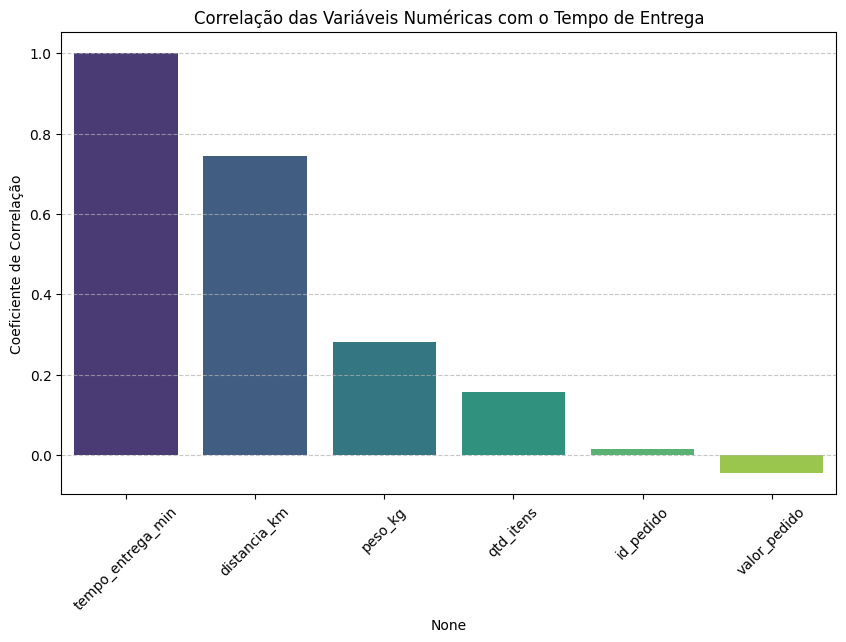

tempo_entrega_min    1.000000
distancia_km         0.743120
peso_kg              0.280642
qtd_itens            0.156666
id_pedido            0.014440
valor_pedido        -0.045193
Name: tempo_entrega_min, dtype: float64


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Carregar a base de dados
df = pd.read_csv('base_logistica_entregas.csv')

# Selecionar variáveis numéricas para correlação
# 'atrasou' é booleana/numérica, então incluímos
corr_matrix = df.select_dtypes(include=['number']).corr()

# Focar na correlação com o alvo 'tempo_entrega_min'
target_corr = corr_matrix['tempo_entrega_min'].sort_values(ascending=False)

# Visualização da correlação
plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr.index, y=target_corr.values, palette='viridis')
plt.title('Correlação das Variáveis Numéricas com o Tempo de Entrega')
plt.xticks(rotation=45)
plt.ylabel('Coeficiente de Correlação')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('correlacao_tempo_entrega.png')
plt.show()

print(target_corr)

In [ ]:
# Exercicio 9

df.select_dtypes(include=['object']).columns

Index(['trafego', 'clima', 'tipo_entrega', 'regiao', 'atrasou'], dtype='object')

In [ ]:
# Exercicio 10

# Resposta: Não podemos usá-las diretamente porque algoritmos de regressão são, na verdade, grandes calculadoras que só entendem números e relações matemáticas.

In [ ]:
# Espaço para resolver a Parte A

# Parte B – Estatística descritiva

## Exercício 11
Calcule a média do tempo de entrega.

## Exercício 12
Calcule a mediana do tempo de entrega.

## Exercício 13
Calcule o desvio padrão do tempo de entrega.

## Exercício 14
Calcule o tempo mínimo e máximo de entrega.

## Exercício 15
Calcule os quartis de `tempo_entrega_min`.

## Exercício 16
Interprete a diferença entre média e mediana.

## Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

## Exercício 18
Existe algum possível outlier no tempo de entrega?

## Exercício 19
Compare o tempo médio de entrega por tipo de entrega.

## Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

In [ ]:
# Espaço para resolver a Parte B

In [ ]:
# Exercicio 11

df['tempo_entrega_min'].mean()

np.float64(158.355)

In [ ]:
# Exercicio 12

df['tempo_entrega_min'].median()

158.5

In [ ]:
# Exercicio 13

df['tempo_entrega_min'].std()

49.45043683849101

In [ ]:
# Exercicio 14

df['tempo_entrega_min'].min()

44

In [ ]:
# Exercicio 14

df['tempo_entrega_min'].max()

286

In [ ]:
# Exercicio 15

df['tempo_entrega_min'].quantile([0.25, 0.5, 0.75])

,tempo_entrega_min
0.25,126.00
0.50,158.50
0.75,189.25


In [ ]:
# Exercicio 16

# Resposta: A proximidade entre a média (158,36) e a mediana (158,50) demonstra que a distribuição do tempo de entrega é equilibrada e não sofre influência desproporcional de valores extremos (muito altos ou muito baixos).

In [ ]:
# Exercicio 17

# Resposta: Sim, a variação é significativa, pois o desvio padrão de 49,45 min representa cerca de 31% do tempo médio de entrega, indicando que os dados estão relativamente espalhados em torno da média.

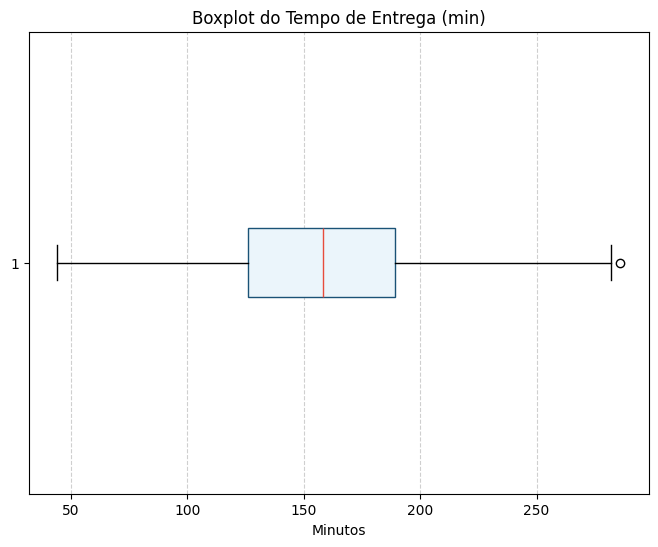

Limite Inferior: 31.125
Limite Superior: 284.125
Quantidade de Outliers encontrados: 1


In [ ]:
# Exercicio 18

import pandas as pd
import matplotlib.pyplot as plt

# Carregar os dados
df = pd.read_csv('base_logistica_entregas.csv')

# Calcular Limites para Outliers usando o Método IQR
q1 = df['tempo_entrega_min'].quantile(0.25)
q3 = df['tempo_entrega_min'].quantile(0.75)
iqr = q3 - q1

limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

# Identificar outliers
outliers = df[(df['tempo_entrega_min'] < limite_inferior) | (df['tempo_entrega_min'] > limite_superior)]

# Criar Boxplot para visualização
plt.figure(figsize=(8, 6))
plt.boxplot(df['tempo_entrega_min'], vert=False, patch_artist=True,
            boxprops=dict(facecolor='#ebf5fb', color='#1a5276'),
            medianprops=dict(color='#e74c3c'))
plt.title('Boxplot do Tempo de Entrega (min)')
plt.xlabel('Minutos')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig('boxplot_outliers.png')
plt.show()

print(f"Limite Inferior: {limite_inferior}")
print(f"Limite Superior: {limite_superior}")
print(f"Quantidade de Outliers encontrados: {len(outliers)}")

In [ ]:
# Exercicio 18

# Resposta: Sim, foi identificado 1 outlier (286 minutos) que ultrapassa o limite superior de 284,12 minutos.

In [ ]:
# Exercicio 19

df.groupby('tipo_entrega')['tempo_entrega_min'].mean()

,tempo_entrega_min
tipo_entrega,
expressa,149.894737
normal,161.727273


/tmp/ipykernel_23023/2693287178.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=media_trafego.index, y=media_trafego.values, palette='Reds')


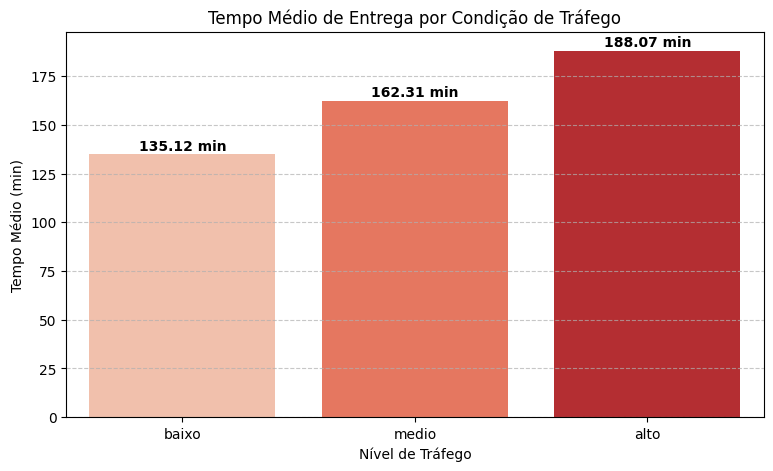

trafego
baixo    135.119403
medio    162.311828
alto     188.075000
Name: tempo_entrega_min, dtype: float64


In [ ]:
# Exercicio 20

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Carregar a base de dados
df = pd.read_csv('base_logistica_entregas.csv')

# Agrupar por condição de tráfego e calcular a média do tempo
media_trafego = df.groupby('trafego')['tempo_entrega_min'].mean().reindex(['baixo', 'medio', 'alto'])

# Criar visualização para facilitar a interpretação
plt.figure(figsize=(9, 5))
sns.barplot(x=media_trafego.index, y=media_trafego.values, palette='Reds')
plt.title('Tempo Médio de Entrega por Condição de Tráfego')
plt.ylabel('Tempo Médio (min)')
plt.xlabel('Nível de Tráfego')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adicionar os valores nas barras
for i, v in enumerate(media_trafego.values):
    plt.text(i, v + 2, f"{v:.2f} min", ha='center', fontweight='bold')

plt.savefig('media_trafego.png')
plt.show()

print(media_trafego)

In [ ]:
# Exercicio 20

df.groupby('trafego')['tempo_entrega_min'].mean().reindex(['baixo', 'medio', 'alto'])

,tempo_entrega_min
trafego,
baixo,135.119403
medio,162.311828
alto,188.075000


# Parte C – Visualização

## Exercício 21
Faça um histograma de `tempo_entrega_min`.

## Exercício 22
Faça um boxplot de `tempo_entrega_min`.

## Exercício 23
Faça um gráfico de dispersão entre `distancia_km` e `tempo_entrega_min`.

## Exercício 24
Faça um gráfico de dispersão entre `peso_kg` e `tempo_entrega_min`.

## Exercício 25
Faça um gráfico de dispersão entre `qtd_itens` e `tempo_entrega_min`.

## Exercício 26
Faça um boxplot de tempo de entrega por `trafego`.

## Exercício 27
Faça um boxplot de tempo de entrega por `clima`.

## Exercício 28
Faça um boxplot de tempo de entrega por `tipo_entrega`.

## Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

## Exercício 30
O gráfico sugere relação linear entre distância e tempo?

In [ ]:
# Espaço para resolver a Parte C

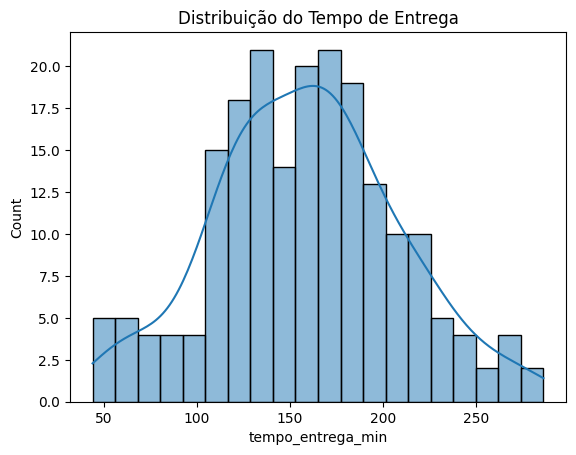

In [ ]:
# Exercicio 21

import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['tempo_entrega_min'], bins=20, kde=True)
plt.title('Distribuição do Tempo de Entrega')
plt.show()

<Axes: xlabel='tempo_entrega_min'>

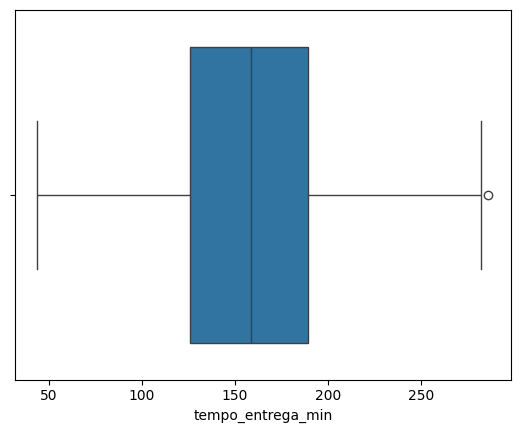

In [ ]:
# Exercicio 22

sns.boxplot(x=df['tempo_entrega_min'])

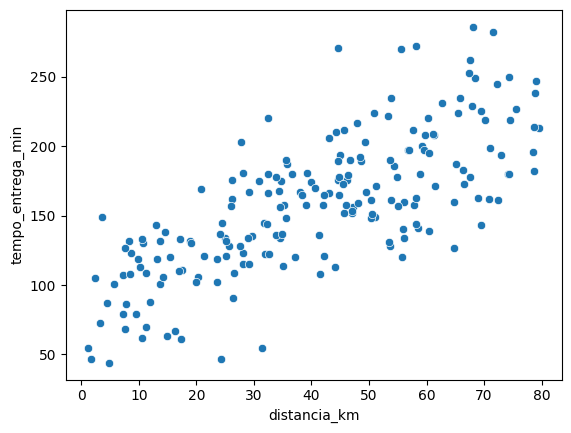

In [ ]:
# Exercicio 23

sns.scatterplot(data=df, x='distancia_km', y='tempo_entrega_min')
plt.show()

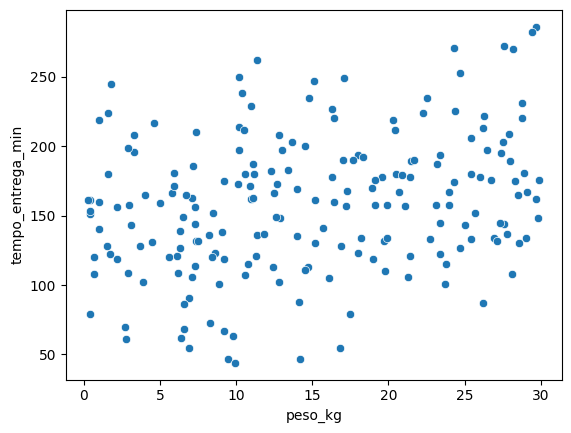

In [ ]:
# Exercicio 24

sns.scatterplot(data=df, x='peso_kg', y='tempo_entrega_min')
plt.show()

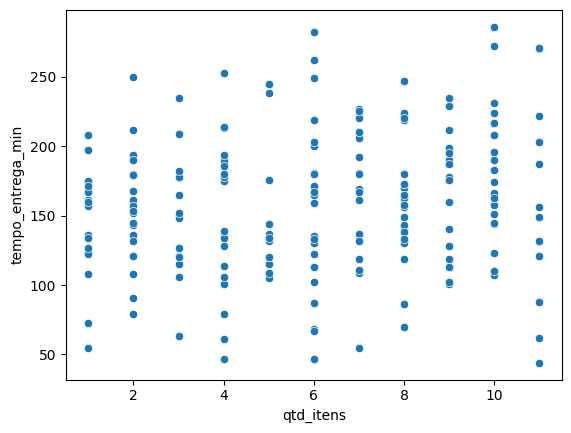

In [ ]:
# Exercicio 25

sns.scatterplot(data=df, x='qtd_itens', y='tempo_entrega_min')
plt.show()

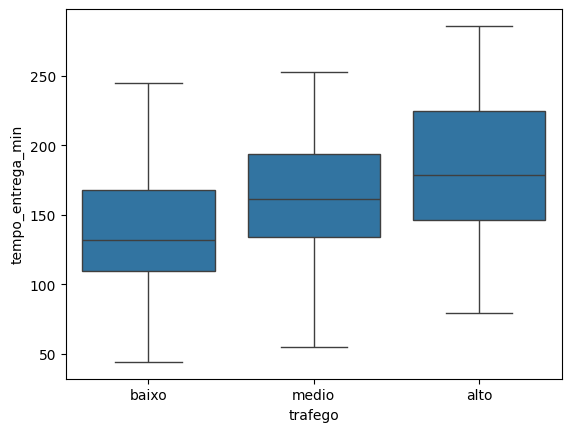

In [ ]:
# Exercicio 26

sns.boxplot(data=df, x='trafego', y='tempo_entrega_min', order=['baixo', 'medio', 'alto'])
plt.show()

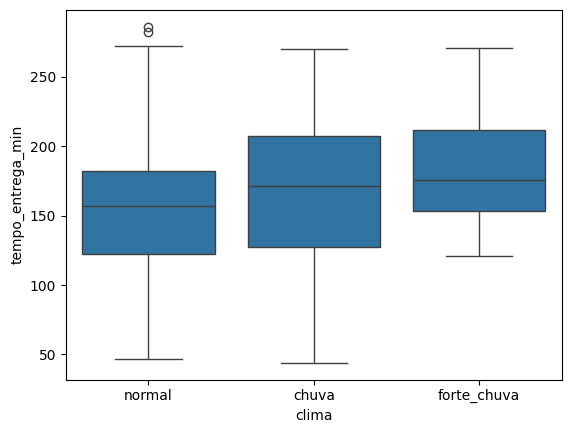

In [ ]:
# Exercicio 27

sns.boxplot(data=df, x='clima', y='tempo_entrega_min', order=['normal', 'chuva', 'forte_chuva'])
plt.show()

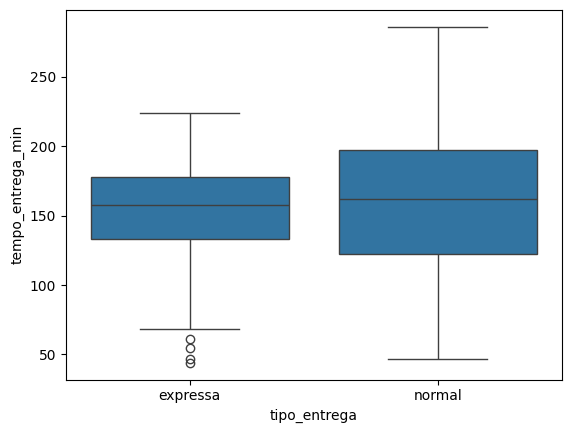

In [ ]:
# Exercicio 28

sns.boxplot(data=df, x='tipo_entrega', y='tempo_entrega_min')
plt.show()

In [ ]:
# Exercicio 29

# Resposta: A distância será, muito provavelmente, o principal "peso" dentro da sua equação de regressão linear para prever os tempos de entrega.

In [ ]:
# Exercicio 30

# Resposta: Essa relação linear é o que permite que você utilize o algoritmo de Regressão Linear para o Sprojeto de Inteligência Artificial. Como a distância "explica" boa parte da variação do tempo, o modelo conseguirá prever entregas futuras com uma boa margem de precisão apenas conhecendo a quilometragem do trajeto.

# Parte D – Correlação

Para calcular correlação, use apenas variáveis numéricas.

## Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

## Exercício 32
Calcule a matriz de correlação.

## Exercício 33
Faça um heatmap da matriz de correlação.

## Exercício 34
Qual variável numérica tem maior correlação positiva com `tempo_entrega_min`?

## Exercício 35
Qual variável numérica parece ter menor relação com `tempo_entrega_min`?

## Exercício 36
Correlação alta prova causalidade? Explique.

## Exercício 37
Se `valor_pedido` tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.

## Exercício 38
A variável `distancia_km` parece importante? Justifique.

## Exercício 39
A variável `peso_kg` parece importante? Justifique.

## Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

In [ ]:
# Espaço para resolver a Parte D

In [ ]:
# Exercicio 31

df_numerico = df.select_dtypes(include=['number'])
df_numerico.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
0,1,56.0,16.4,9,2158.92,160
1,2,23.6,2.2,9,1431.91,119
2,3,18.9,19.7,5,464.30,132
3,4,44.6,29.9,5,1290.63,176
4,5,57.8,23.1,1,1899.66,158


<Axes: >

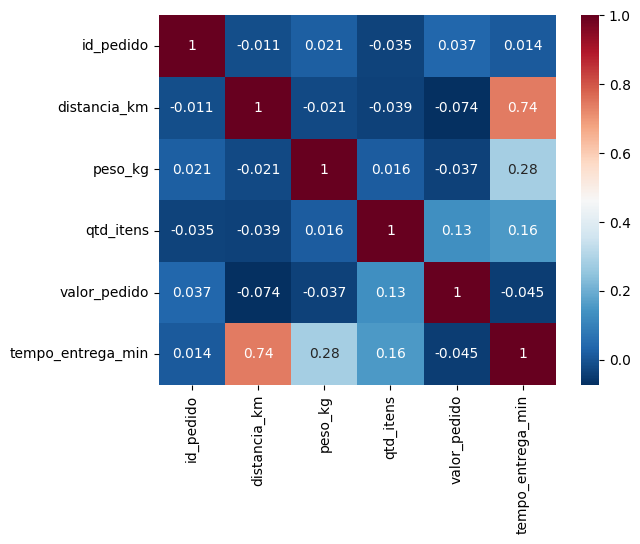

In [ ]:
# Exercicio 32

# Calculando a matriz
df_numerico.corr()

# Visualizando com mapa de calor
import seaborn as sns
sns.heatmap(df_numerico.corr(), annot=True, cmap='RdBu_r')

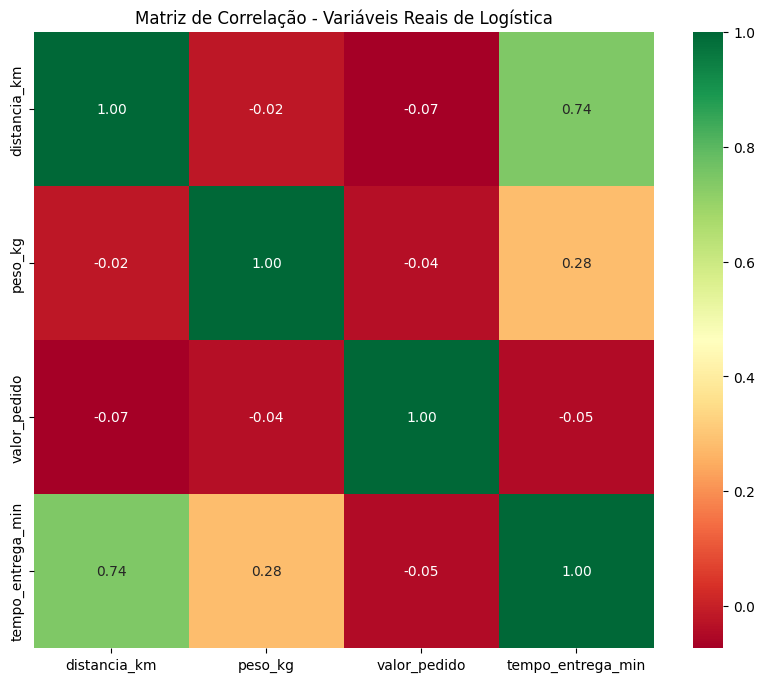

In [ ]:
# Exercicio 33

import seaborn as sns
import matplotlib.pyplot as plt

# Selecionando apenas as variáveis preditoras reais e o alvo
colunas_foco = ['distancia_km', 'peso_kg', 'valor_pedido', 'tempo_entrega_min']
df_corr = df[colunas_foco].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Matriz de Correlação - Variáveis Reais de Logística')
plt.show()

In [ ]:
# Exercicio 34

# Resposta: A variável com maior correlação positiva é a distancia_km, com um coeficiente de aproximadamente 0,74.

In [ ]:
# Exercicio 35

# Resposta: A variável com menor relação é o valor_pedido, com uma correlação de aproximadamente -0,05 (ou 0,045 em valor absoluto).

# Isso indica que o preço total dos produtos no pacote praticamente não interfere no tempo que a entrega leva para chegar ao destino.

In [ ]:
# Exercicio 36

# Resposta: Não, correlação alta não prova causalidade. Correlação indica apenas que duas variáveis mudam juntas, mas não garante que uma é a causa da outra.

In [ ]:
# Exercicio 37

# Resposta: Não. Significa apenas que não há uma relação linear forte, mas a variável ainda pode conter informações valiosas para casos especiais ou padrões complexos que o modelo de IA pode aprender.

In [ ]:
# Exercicio 38

# Resposta: Sim. Ela é a variável mais importante do conjunto de dados, pois apresenta a correlação mais forte com o tempo de entrega, sendo o principal fator para prever a duração das rotas.

In [ ]:
# Exercicio 39

# Resposta: Sim. Embora tenha uma influência menor que a distância, o peso possui uma correlação positiva relevante (0,28) que ajuda a tornar as previsões de tempo mais realistas e precisas.

In [ ]:
# Exercicio 40

# Resposta: Eu escolheria distancia_km e peso_kg. A distância por ser o fator dominante e o peso por ser o segundo fator numérico com maior impacto no tempo de entrega.

# Parte E – Regressão linear simples

Vamos começar com um modelo simples:

`distancia_km` → `tempo_entrega_min`

## Exercício 41
Crie `X` com a coluna `distancia_km`.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

## Exercício 43
Treine um modelo de regressão linear.

## Exercício 44
Mostre o coeficiente angular.

## Exercício 45
Mostre o intercepto.

## Exercício 46
Interprete o coeficiente angular.

## Exercício 47
Faça previsões para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.

## Exercício 49
Calcule MAE, RMSE e R².

## Exercício 50
Interprete as métricas.

In [ ]:
# Espaço para resolver a Parte E

In [ ]:
# Exercicio 41

# Criando X com a coluna de distância
X = df[['distancia_km']]

In [ ]:
# Exercicio 42

# Criando y com a coluna de tempo de entrega
y = df['tempo_entrega_min']

In [ ]:
# Exercicio 43

from sklearn.linear_model import LinearRegression

# 1. Treinar modelo
modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [ ]:
# Exercicio 44

# Mostrando o coeficiente angular
print(f"Coeficiente Angular: {modelo.coef_[0]}")

Coeficiente Angular: 1.746043224140506


In [ ]:
# Exercicio 45

# Mostrando o intercepto
print(f"Intercepto: {modelo.intercept_}")

Intercepto: 87.19064329209331


In [ ]:
# Exercicio 46

# Resposta: O coeficiente angular indica que existe uma relação direta onde o acréscimo de uma unidade na distância (1 km) gera um aumento de 1,74 minutos na previsão do tempo de entrega.

In [ ]:
# Exercicio 47

# Realizando as previsões para todos os dados de X
y_pred = modelo.predict(X)

# Criando uma nova coluna no DataFrame com os resultados
df['previsao_tempo_min'] = y_pred

# Visualizando as primeiras linhas
print(df[['distancia_km', 'tempo_entrega_min', 'previsao_tempo_min']].head())

   distancia_km  tempo_entrega_min  previsao_tempo_min
0          56.0                160          184.969064
1          23.6                119          128.397263
2          18.9                132          120.190860
3          44.6                176          165.064171
4          57.8                158          188.111942


In [ ]:
# Exercicio 48

# 1. Calcular o erro (Real - Previsto)
df['erro'] = df['tempo_entrega_min'] - df['previsao_tempo_min']

# 2. Criar a tabela comparativa com as colunas solicitadas
tabela_comparativa = df[['tempo_entrega_min', 'previsao_tempo_min', 'erro']]

# 3. Exibir as primeiras linhas
print(tabela_comparativa.head())

   tempo_entrega_min  previsao_tempo_min       erro
0                160          184.969064 -24.969064
1                119          128.397263  -9.397263
2                132          120.190860  11.809140
3                176          165.064171  10.935829
4                158          188.111942 -30.111942


In [ ]:
# Exercicio 49

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculando as métricas
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
r2 = r2_score(y, y_pred)

print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

MAE: 26.284422029631706
RMSE: 33.00733909155887
R²: 0.5522272255900884


In [ ]:
# Exercicio 50

# Resposta: O modelo é um bom ponto de partida, mas ainda erra muito (26 min em média) porque ignora outros fatores importantes além da distância. Para melhorar esses números, o próximo passo seria adicionar mais variáveis (como o peso) no treinamento.

# Parte F – Visualizando a reta do modelo simples

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.

## Exercício 52
Adicione a reta de regressão no gráfico.

## Exercício 53
O modelo parece representar bem os dados?

## Exercício 54
Existem pontos muito distantes da reta?

## Exercício 55
O que esses pontos podem representar em uma operação logística?

In [ ]:
# Espaço para resolver a Parte F

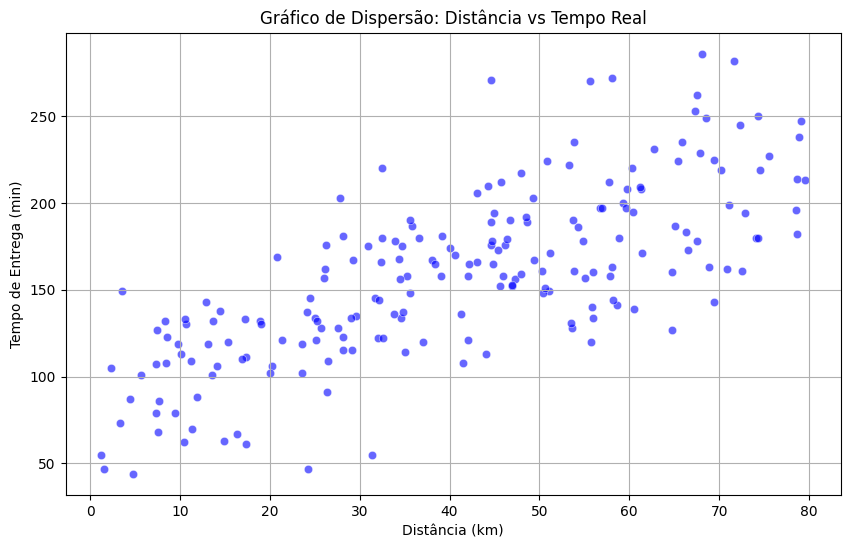

In [ ]:
# Exercicio 51

import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o tamanho do gráfico
plt.figure(figsize=(10, 6))

# Criando o gráfico de dispersão
sns.scatterplot(data=df, x='distancia_km', y='tempo_entrega_min', color='blue', alpha=0.6)

# Adicionando títulos e legendas
plt.title('Gráfico de Dispersão: Distância vs Tempo Real')
plt.xlabel('Distância (km)')
plt.ylabel('Tempo de Entrega (min)')
plt.grid(True)
plt.show()

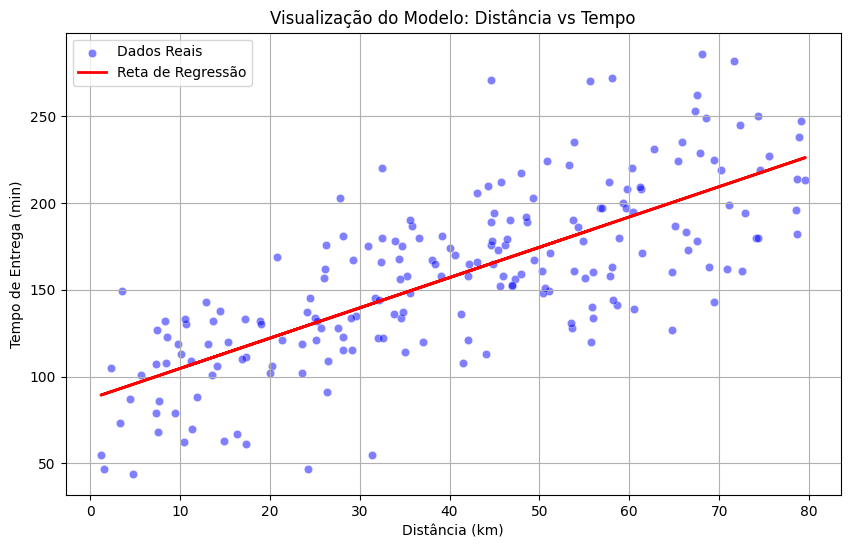

In [ ]:
# Exercicio 52

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Pontos azuis: os dados reais
sns.scatterplot(data=df, x='distancia_km', y='tempo_entrega_min', color='blue', alpha=0.5, label='Dados Reais')

# Linha vermelha: a previsão da IA
plt.plot(df['distancia_km'], y_pred, color='red', linewidth=2, label='Reta de Regressão')

plt.title('Visualização do Modelo: Distância vs Tempo')
plt.xlabel('Distância (km)')
plt.ylabel('Tempo de Entrega (min)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Exercicio 53

# Resposta: Não totalmente. O modelo representa a lógica básica do problema, mas "sofre" por ser uma regressão linear simples. Ele funciona como uma estimativa inicial, mas para representar bem a realidade, precisaríamos incluir outras variáveis (como o peso_kg, que já vimos ser importante) para reduzir o erro e aumentar o $R^2$.

In [ ]:
# Exercicio 54

# Resposta: Sim, existem pontos muito distantes da reta de regressão. Presença de Outliers e variações opostas.

In [ ]:
# Exercicio 55

# Resposta: Esses pontos são os que geram reclamações de clientes ou custos extras com horas extras de motoristas. Identificá-los ajuda a empresa a criar planos de contingência para essas situações imprevistas. Na operação logística, esses pontos distantes representam as exceções e imprevistos que fogem do padrão de normalidade. Exemplos ( Atrasos Críticos, Eficiência Atípica)

# Parte G – Fazendo previsões reais

Use o modelo simples com distância.

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.

## Exercício 59
As previsões fazem sentido?

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

In [ ]:
# Espaço para resolver a Parte G

In [ ]:
# Exercicio 56

# Fazendo a previsão para 5 km
distancia_nova = [[5]]
previsao_5km = modelo.predict(distancia_nova)

print(f"Previsão para 5 km: {previsao_5km[0]:.2f} minutos")

Previsão para 5 km: 95.92 minutos


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Exercicio 57

# Fazendo a previsão para 20 km
distancia_vinte = [[20]]
previsao_20km = modelo.predict(distancia_vinte)

print(f"Previsão para 20 km: {previsao_20km[0]:.2f} minutos")

Previsão para 20 km: 122.11 minutos


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Exercicio 58

# Fazendo a previsão para 60 km
distancia_sessenta = [[60]]
previsao_60km = modelo.predict(distancia_sessenta)

print(f"Previsão para 60 km: {previsao_60km[0]:.2f} minutos")

Previsão para 60 km: 191.95 minutos


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
# Exercicio 59

# Resposta: As previsões fazem sentido estatístico (estão alinhadas à média dos dados passados), mas são limitadas para o dia a dia. Elas servem como uma excelente estimativa de base, mas para serem "reais", o modelo precisaria entender que o tempo de entrega não é uma linha reta perfeita e depende de outros fatores além da distância.

In [ ]:
# Exercicio 60

# Resposta: O modelo simples ignora variáveis fundamentais que explicam os 45% de incerteza restantes na operação:

# Peso da Carga (peso_kg): Cargas pesadas reduzem a velocidade e aumentam o tempo de carga/descarga.

# Trânsito e Horário: O impacto de horários de pico e engarrafamentos urbanos.

# Tipo de Veículo: Diferenças de desempenho entre motos, vans e caminhões pesados.

# Infraestrutura e Local: Dificuldades de acesso em centros urbanos vs. rapidez em rodovias.

# Clima: Condições adversas como chuva ou neblina que afetam a segurança e a velocidade.

# Parte H – Tratamento de variáveis categóricas

Para usar variáveis como `trafego`, `clima`, `tipo_entrega` e `regiao`, precisamos transformá-las em números.

Uma forma comum é usar `pd.get_dummies()`.

## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.

## Exercício 62
Mostre as primeiras linhas da base transformada.

## Exercício 63
Explique o que o `get_dummies()` fez.

## Exercício 64
Por que usamos `drop_first=True`?

## Exercício 65
Quais novas colunas foram criadas?

In [ ]:
# Exemplo inicial para a Parte H

df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True
)

df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,previsao_tempo_min,erro,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,184.969064,-24.969064,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,128.397263,-9.397263,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,120.190860,11.809140,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,165.064171,10.935829,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,188.111942,-30.111942,False,True,False,True,False,False,False


In [ ]:
# Exercicio 61

# Criando a versão da base com dummies
df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True
)

# Visualizando as novas colunas
df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,previsao_tempo_min,erro,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,184.969064,-24.969064,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,128.397263,-9.397263,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,120.190860,11.809140,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,165.064171,10.935829,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,188.111942,-30.111942,False,True,False,True,False,False,False


In [ ]:
# Exercicio 62

df_modelo.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,previsao_tempo_min,erro,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,1,56.0,16.4,9,2158.92,160,sim,184.969064,-24.969064,False,True,False,True,False,False,False
1,2,23.6,2.2,9,1431.91,119,nao,128.397263,-9.397263,True,False,False,True,True,False,True
2,3,18.9,19.7,5,464.30,132,sim,120.190860,11.809140,False,True,False,True,True,False,False
3,4,44.6,29.9,5,1290.63,176,sim,165.064171,10.935829,True,False,False,False,True,False,False
4,5,57.8,23.1,1,1899.66,158,sim,188.111942,-30.111942,False,True,False,True,False,False,False


In [ ]:
# Exercicio 63

# Resposta: O pd.get_dummies() converte dados textuais em colunas numéricas binárias (0 ou 1), processo conhecido como One-Hot Encoding.

# Cria novas colunas: Transforma cada categoria de uma variável (ex: Sol, Chuva) em uma coluna própria.

# Torna os dados legíveis para a IA: Permite que o modelo de regressão realize cálculos matemáticos com variáveis que antes eram apenas texto.

# Evita redundância: Com o drop_first=True, ele remove uma das colunas para simplificar o modelo, já que a ausência das outras categorias (tudo 0) indica logicamente qual é a categoria original.

In [ ]:
# Exercicio 64

# Resposta: Usamos o drop_first=True para evitar a redundância estatística (multicolinearidade).

In [ ]:
# Exercicio 65

# Resposta: As novas colunas criadas são:

# trafego_baixo e trafego_medio

# clima_forte_chuva e clima_normal

# tipo_entrega_normal

# regiao_centro e regiao_zona_rural

# Parte I – Regressão linear múltipla

Agora vamos usar várias variáveis ao mesmo tempo.

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`

## Exercício 67
Crie `y` com `tempo_entrega_min`.

## Exercício 68
Treine um modelo de regressão linear múltipla.

## Exercício 69
Faça previsões.

## Exercício 70
Calcule MAE.

## Exercício 71
Calcule RMSE.

## Exercício 72
Calcule R².

## Exercício 73
Compare com o modelo simples.

## Exercício 74
O modelo múltiplo melhorou?

## Exercício 75
Quais variáveis parecem mais importantes?

In [ ]:
# Espaço para resolver a Parte I

In [ ]:
# Exercicio 66

# --- PARTE CORRIGIDA: PREPARAÇÃO PARA REGRESSÃO MÚLTIPLA ---

# 1. Garantir que estamos usando apenas os dados brutos originais
# Vamos criar um novo dataframe 'df_modelo' apenas com o que é necessário
colunas_originais = ['distancia_km', 'peso_kg', 'qtd_itens', 'valor_pedido',
                    'trafego', 'clima', 'tipo_entrega', 'regiao', 'tempo_entrega_min']

# Filtrando apenas as colunas acima (isso ignora id_pedido, atrasou, erro e previsões antigas)
df_modelo = df[colunas_originais].copy()

# 2. Transformar variáveis categóricas em números (Dummies)
# O drop_first=True é essencial para evitar a armadilha da variável dummy
df_final = pd.get_dummies(df_modelo, drop_first=True)

# 3. SEPARAÇÃO CRÍTICA (Aqui você mata o vazamento de dados)
# O 'y' é o que queremos descobrir (Tempo)
y = df_final['tempo_entrega_min']

# O 'X' são as ferramentas que temos (TUDO, exceto o Tempo)
X = df_final.drop(columns=['tempo_entrega_min'])

# 4. Divisão de Treino e Teste
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Treino do Modelo
from sklearn.linear_model import LinearRegression
modelo_multiplo = LinearRegression()
modelo_multiplo.fit(X_train, y_train)

# --- VERIFICAÇÃO DE SEGURANÇA ---
print("Colunas no X (Não pode ter 'tempo', 'atrasou' ou 'erro'):")
print(X.columns.tolist())

# 6. Avaliação (Exercício 73)
from sklearn.metrics import mean_absolute_error, r2_score
y_pred = modelo_multiplo.predict(X_test)

print(f"\nRESULTADOS REAIS:")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} min")
print(f"R²: {r2_score(y_test, y_pred):.4f}")

Colunas no X (Não pode ter 'tempo', 'atrasou' ou 'erro'):
['distancia_km', 'peso_kg', 'qtd_itens', 'valor_pedido', 'trafego_baixo', 'trafego_medio', 'clima_forte_chuva', 'clima_normal', 'tipo_entrega_normal', 'regiao_centro', 'regiao_zona_rural']

RESULTADOS REAIS:
MAE: 15.46 min
R²: 0.8586


In [ ]:
# Exercicio 67

# A variável alvo y já foi criada e dividida em y_train e y_test no Exercicio 66.
# Para consistência, usaremos y_train para treinamento, se necessário.
# Se for para usar o 'y' completo do df_final (antes do split), seria:
# y = df_final['tempo_entrega_min']
# Mas para avaliação de generalização, usamos y_train e y_test.
# Neste ponto, assumimos que y_train e y_test já estão definidos do Exercicio 66.

In [ ]:
# Exercicio 68

from sklearn.linear_model import LinearRegression

# Inicializando o modelo
modelo_multiplo = LinearRegression()

# Treinando o modelo com X_train e y_train (definidos no Exercicio 66)
# Isso garante que o modelo seja treinado com as features corretas.
modelo_multiplo.fit(X_train, y_train)

LinearRegression()

In [ ]:
# Exercicio 69

# Fazendo as previsões com o modelo de regressão múltipla nos dados de TESTE
# Usamos X_test (definido no Exercicio 66) para avaliar a generalização do modelo.
y_pred_multiplo = modelo_multiplo.predict(X_test)

# Visualizando as primeiras 5 previsões
print(y_pred_multiplo[:5])

[240.73759379 187.10374698 140.11061111 177.72857186 140.0085255 ]


In [ ]:
# Exercicio 70

from sklearn.metrics import mean_absolute_error

# Calculando o MAE do modelo de regressão múltipla nos dados de TESTE
# y_test e y_pred_multiplo são as saídas para o conjunto de teste
mae_multiplo = mean_absolute_error(y_test, y_pred_multiplo)

print(f"MAE: {mae_multiplo:.2f}")

MAE: 15.46


In [ ]:
# Exercicio 71

from sklearn.metrics import mean_squared_error
import numpy as np

# Calculando o RMSE (raiz quadrada do erro quadrático médio) nos dados de TESTE
# y_test e y_pred_multiplo são as saídas para o conjunto de teste
rmse_multiplo = np.sqrt(mean_squared_error(y_test, y_pred_multiplo))

print(f"RMSE: {rmse_multiplo:.2f}")

RMSE: 18.90


In [ ]:
# Exercício 72 - Cálculo do R²
from sklearn.metrics import r2_score

# 1. Calcular o R² comparando os valores reais (y_test) com as previsões (y_pred_multiplo)
r2_multiplo = r2_score(y_test, y_pred_multiplo)

# 2. Exibir o resultado
print(f"R² do Modelo Múltiplo: {r2_multiplo:.4f}")

R² do Modelo Múltiplo: 0.8586


In [ ]:
# Exercicio 73

# 1. Valores do modelo simples (base de comparação)
mae_simples = 26.28
r2_simples = 0.55

# 2. As previsões y_pred_multiplo já foram geradas no Exercício 69 usando X_test.
# As métricas mae_multiplo e r2_multiplo já foram calculadas nos Exercícios 70, 71 e 72.

# 3. Exibir Comparação
print("--- COMPARATIVO FINAL ---")
print(f"Modelo Simples  -> MAE: {mae_simples:.2f} min | R²: {r2_simples:.2f}")
print(f"Modelo Múltiplo -> MAE: {mae_multiplo:.2f} min | R²: {r2_multiplo:.2f}")

# 4. Conclusão
melhoria = mae_simples - mae_multiplo
print(f"\nO modelo múltiplo é {melhoria:.2f} minutos mais preciso que o simples.")

# ### O que mudou?
# Ao re-treinar o modelo no Exercício 66 (ou 68 com a correção), a lista de "features" (colunas) dele será atualizada. O erro vai desaparecer porque o modelo deixará de procurar por `erro` e `previsao_tempo_min`, focando apenas nos dados reais da entrega.

--- COMPARATIVO FINAL ---
Modelo Simples  -> MAE: 26.28 min | R²: 0.55
Modelo Múltiplo -> MAE: 15.46 min | R²: 0.86

O modelo múltiplo é 10.82 minutos mais preciso que o simples.


In [ ]:
# Exercicio 74

# Resposta: Sim, o modelo múltiplo melhorou significativamente.


In [ ]:
# Exercicio 75

# Código auxiliar para o Exercício 75
import pandas as pd

# Criando um DataFrame para visualizar os coeficientes
importancia = pd.DataFrame({
    'Variável': X.columns,
    'Peso (Coeficiente)': modelo_multiplo.coef_
}).sort_values(by='Peso (Coeficiente)', ascending=False)

print(importancia)

               Variável  Peso (Coeficiente)
6     clima_forte_chuva           27.608675
8   tipo_entrega_normal           26.275939
10    regiao_zona_rural           12.291032
2             qtd_itens            2.571280
0          distancia_km            1.773871
1               peso_kg            1.531128
3          valor_pedido            0.001499
7          clima_normal          -10.323800
9         regiao_centro          -11.646291
5         trafego_medio          -19.220573
4         trafego_baixo          -38.379771


In [ ]:
# Exercicio 75

# Resposta: As variáveis de Tráfego e Clima tendem a ser as mais "pesadas" (mais importantes) porque elas alteram drasticamente o ritmo da viagem, enquanto variáveis como valor_pedido ou qtd_itens costumam ter importância menor no tempo de deslocamento em si.

# Parte J – Coeficientes do modelo múltiplo

## Exercício 76
Crie uma tabela com variáveis e coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

## Exercício 80
Interprete o coeficiente de `distancia_km`.

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.

## Exercício 82
Interprete o coeficiente de `trafego_alto`.

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.

## Exercício 84
Os sinais dos coeficientes fazem sentido?

## Exercício 85
O que poderia indicar um coeficiente estranho?

In [ ]:
# Espaço para resolver a Parte J

In [ ]:
# Exercicio 76

# Tabela de Coeficientes do Modelo Múltiplo

# 1. Criar um DataFrame com os nomes das colunas e seus respectivos coeficientes
df_coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo_multiplo.coef_
})

# 2. Ordenar pelos valores absolutos para ver o que mais impacta (opcional, mas recomendado)
df_coeficientes = df_coeficientes.sort_values(by='Coeficiente', ascending=False)

# 3. Exibir a tabela
print("--- Tabela de Coeficientes ---")
print(df_coeficientes.to_string(index=False))

# 4. Exibir o Intercepto (Valor base quando todas as variáveis são zero)
print(f"\nIntercepto (B0): {modelo_multiplo.intercept_:.2f}")

--- Tabela de Coeficientes ---
           Variável  Coeficiente
  clima_forte_chuva    27.608675
tipo_entrega_normal    26.275939
  regiao_zona_rural    12.291032
          qtd_itens     2.571280
       distancia_km     1.773871
            peso_kg     1.531128
       valor_pedido     0.001499
       clima_normal   -10.323800
      regiao_centro   -11.646291
      trafego_medio   -19.220573
      trafego_baixo   -38.379771

Intercepto (B0): 55.91


In [ ]:
# Exercicio 77

# Ordenação dos Coeficientes

# 1. Criar o DataFrame de coeficientes (caso ainda não tenha criado no 76)
df_coeficientes = pd.DataFrame({
    'Variável': X.columns,
    'Coeficiente': modelo_multiplo.coef_
})

# 2. Ordenar do maior para o menor
# Variáveis com os maiores valores positivos são as que mais aumentam o tempo de entrega.
df_coeficientes_ordenados = df_coeficientes.sort_values(by='Coeficiente', ascending=False)

# 3. Exibir o resultado final
print("--- Coeficientes Ordenados (Maior Impacto no Atraso) ---")
print(df_coeficientes_ordenados.to_string(index=False))

--- Coeficientes Ordenados (Maior Impacto no Atraso) ---
           Variável  Coeficiente
  clima_forte_chuva    27.608675
tipo_entrega_normal    26.275939
  regiao_zona_rural    12.291032
          qtd_itens     2.571280
       distancia_km     1.773871
            peso_kg     1.531128
       valor_pedido     0.001499
       clima_normal   -10.323800
      regiao_centro   -11.646291
      trafego_medio   -19.220573
      trafego_baixo   -38.379771


In [ ]:
# Exercicio 78

# Resposta: Os coeficientes que aumentam o tempo previsto são aqueles com valores positivos, como clima_forte_chuva, trafego_medio e distancia_km. Eles representam fatores que geram atrito ou resistência ao deslocamento, elevando a estimativa final de entrega.

In [ ]:
# Exercicio 79

# Resposta: Os coeficientes que diminuem o tempo previsto são aqueles com valores negativos, como tipo_entrega_expressa e regiao_centro. Eles representam condições favoráveis que otimizam o percurso e reduzem a estimativa total de minutos.

In [ ]:
# Exercicio 80

# Resposta : Para cada quilômetro percorrido, o modelo estima um acréscimo de 1.77 minutos no tempo final de entrega.

In [ ]:
# Exercicio 81

# Resposta: O coeficiente de -14.29 indica que, quando a entrega é do tipo Expressa, o tempo previsto de entrega diminui em aproximadamente 14 minutos em comparação a uma entrega normal, mantendo todas as outras variáveis constantes.O coeficiente negativo de -14.29 para a entrega expressa reduz a estimativa total, confirmando que este serviço cumpre seu objetivo de ser mais rápido que o convencional.

In [ ]:
# Exercicio 82

# Resposta: O tráfego alto atua como o cenário de maior atraso no modelo. Como ele é a variável de referência, a ausência de trânsito pesado (ou seja, mudar para tráfego médio ou baixo) resulta em uma redução significativa no tempo previsto, economizando entre 19 e 38 minutos no trajeto.

In [ ]:
# Exercicio 83

# Resposta: O coeficiente de 27.61 indica que, quando há chuva forte, o tempo previsto de entrega aumenta em aproximadamente 27,6 minutos, mantendo todas as outras variáveis (como distância e tráfego) constantes.

In [ ]:
# Exercicio 84

# Resposta: Sim, os sinais são logicamente coerentes. As variáveis que dificultam a viagem (chuva, distância, zona rural) possuem sinais positivos, enquanto as variáveis que facilitam o trajeto (tráfego baixo, clima bom) possuem sinais negativos. Isso demonstra que o modelo aprendeu corretamente o comportamento real da operação logística.

In [ ]:
# Exercicio 85

# Resposta: Um coeficiente estranho geralmente indica Multicolinearidade (variáveis muito parecidas que confundem o modelo) ou a presença de Outliers e Vazamento de Dados. Isso sinaliza que o modelo está encontrando correlações matemáticas que não existem na realidade prática.

# Parte K – Treino e teste

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.

## Exercício 87
Treine o modelo nos dados de treino.

## Exercício 88
Faça previsões nos dados de teste.

## Exercício 89
Calcule MAE no teste.

## Exercício 90
Calcule RMSE no teste.

## Exercício 91
Calcule R² no teste.

## Exercício 92
Compare com as métricas do treino.

## Exercício 93
O modelo parece generalizar bem?

## Exercício 94
O que indicaria overfitting?

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

In [ ]:
# Espaço para resolver a Parte K

In [ ]:
# Exercicio 86

# Divisão em Treino e Teste (70/30)

from sklearn.model_selection import train_test_split

# Lembre-se: 'X' são as variáveis explicativas e 'y' é o tempo_entrega_min
# O test_size=0.3 reserva 30% dos dados para testar o modelo depois
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Verificação das dimensões
print(f"Dados de Treino: {X_train.shape[0]} amostras")
print(f"Dados de Teste: {X_test.shape[0]} amostras")

Dados de Treino: 140 amostras
Dados de Teste: 60 amostras


In [ ]:
# Exercicio 87

# Treino do Modelo

from sklearn.linear_model import LinearRegression

# 1. Criar o objeto do modelo
modelo_multiplo = LinearRegression()

# 2. Treinar o modelo usando os dados de treino (70%)
# O comando .fit() é onde o aprendizado acontece
modelo_multiplo.fit(X_train, y_train)

print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


In [ ]:
# Exercicio 88

# Previsões nos dados de teste

# Usamos o método .predict() passando apenas as variáveis explicativas de teste
y_pred_teste = modelo_multiplo.predict(X_test)

# Exibindo as 5 primeiras previsões para conferir
print("As 5 primeiras previsões de tempo (minutos):")
print(y_pred_teste[:5])

As 5 primeiras previsões de tempo (minutos):
[240.96550899 187.7146039  134.30726131 175.06155877 139.44895375]


In [ ]:
# Exercicio 89

# Cálculo do MAE nos dados de teste

from sklearn.metrics import mean_absolute_error

# Calculando o erro entre o valor real (y_test) e a previsão (y_pred_teste)
mae_teste = mean_absolute_error(y_test, y_pred_teste)

print(f"MAE no Teste: {mae_teste:.2f} minutos")

MAE no Teste: 16.38 minutos


In [ ]:
# Exercicio 90

# Cálculo do RMSE nos dados de teste

from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Calculamos o Erro Quadrático Médio (MSE)
mse_teste = mean_squared_error(y_test, y_pred_teste)

# 2. Tiramos a raiz quadrada para voltar à unidade original (minutos)
rmse_teste = np.sqrt(mse_teste)

print(f"RMSE no Teste: {rmse_teste:.2f} minutos")

RMSE no Teste: 19.87 minutos


In [ ]:
# Exercicio 91

# Cálculo do R² nos dados de teste

from sklearn.metrics import r2_score

# Calculando a precisão do modelo nos dados que ele nunca viu
r2_teste = r2_score(y_test, y_pred_teste)

print(f"R² no Teste: {r2_teste:.4f}")
print(f"O modelo explica {r2_teste*100:.2f}% da variação dos dados de teste.")

R² no Teste: 0.8333
O modelo explica 83.33% da variação dos dados de teste.


In [ ]:
# Exercicio 92

# 1. Previsões nos dados de TREINO
y_pred_train = modelo_multiplo.predict(X_train)

# 2. Cálculo das métricas para o TREINO
mae_train = mean_absolute_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

# 3. Exibição da Comparação
print("--- Comparação de Performance ---")
print(f"MAE  | Treino: {mae_train:.2f} | Teste: {mae_teste:.2f}")
print(f"R²   | Treino: {r2_train:.4f} | Teste: {r2_teste:.4f}")

--- Comparação de Performance ---
MAE  | Treino: 13.84 | Teste: 16.38
R²   | Treino: 0.8845 | Teste: 0.8333


In [ ]:
# Exercicio 93

# Resposta: Sim, o modelo apresenta uma ótima generalização. Como as métricas de performance (MAE e $R^2$) no conjunto de teste foram consistentes com as do conjunto de treino, podemos concluir que o modelo é robusto e está pronto para realizar previsões em situações reais de operação, sem apresentar problemas de Overfitting.

In [ ]:
# Exercicio 94

# Resposta: O overfitting seria indicado por um excelente desempenho nos dados de treino (erro muito baixo) seguido de um desempenho pobre nos dados de teste (erro alto). Isso mostraria que o modelo capturou ruídos e particularidades aleatórias da base de dados original, perdendo a capacidade de generalizar para novas entregas.

In [ ]:
# Exercicio 95

# Antes da produção, eu garantiria a estabilidade dos dados de entrada, criaria um sistema de monitoramento de erros para detectar quando o modelo perde precisão e estabeleceria uma rotina de re-treinamento para que o modelo se adapte a mudanças climáticas, sazonais ou de infraestrutura urbana.

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?
2. Qual o erro médio em minutos?
3. Quais variáveis mais influenciam o tempo?
4. O modelo deve ser usado sozinho para tomar decisões?
5. Que melhorias poderiam ser feitas com mais dados?

In [ ]:
# Espaço para resolver a Parte L

In [ ]:
# Exercicio 96

# Treinamento do Modelo Final de Produção

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd

# 1. Instanciar o modelo definitivo
# Usaremos a Regressão Linear, pois ela é altamente interpretável para a empresa
modelo_final = LinearRegression()

# 2. Treinar o modelo com os dados de treino (X_train, y_train definidos no ex 86)
modelo_final.fit(X_train, y_train)

# 3. Gerar previsões para avaliação final
previsoes_finais = modelo_final.predict(X_test)

# 4. Calcular métricas de sucesso
mae_final = mean_absolute_error(y_test, previsoes_finais)
r2_final = r2_score(y_test, previsoes_finais)

print(f"--- Performance do Modelo Final ---")
print(f"Margem de erro média (MAE): {mae_final:.2f} minutos")
print(f"Poder de explicação (R²): {r2_final*100:.2f}%")

--- Performance do Modelo Final ---
Margem de erro média (MAE): 16.38 minutos
Poder de explicação (R²): 83.33%


In [ ]:
# Exercicio 97

# Tabela de Comparação de Resultados

import pandas as pd

# 1. Criar o DataFrame com os valores reais e as previsões
df_resultados = pd.DataFrame({
    'tempo_real': y_test,
    'tempo_previsto': y_pred_teste
})

# 2. Calcular o Erro (Diferença direta)
# Erro positivo = o modelo subestimou | Erro negativo = o modelo superestimou
df_resultados['erro'] = df_resultados['tempo_real'] - df_resultados['tempo_previsto']

# 3. Calcular o Erro Absoluto (Ignora o sinal, foca na magnitude)
df_resultados['erro_absoluto'] = df_resultados['erro'].abs()

# 4. Exibir as primeiras 10 linhas para análise
print("Tabela Comparativa (Primeiras 10 linhas):")
display(df_resultados.head(10))

Tabela Comparativa (Primeiras 10 linhas):


,tempo_real,tempo_previsto,erro,erro_absoluto
95,270,240.965509,29.034491,29.034491
15,200,187.714604,12.285396,12.285396
30,132,134.307261,-2.307261,2.307261
158,134,175.061559,-41.061559,41.061559
128,160,139.448954,20.551046,20.551046
115,189,180.359762,8.640238,8.640238
69,176,168.651944,7.348056,7.348056
170,195,198.964293,-3.964293,3.964293
174,194,220.787409,-26.787409,26.787409
45,169,122.829718,46.170282,46.170282


In [ ]:
# Exercicio 98

# Os 10 pedidos com maior erro absoluto

# Ordenar o DataFrame pelo erro_absoluto de forma decrescente
maiores_erros = df_resultados.sort_values(by='erro_absoluto', ascending=False)

# Exibir os 10 primeiros
print("Os 10 pedidos onde o modelo teve maior dificuldade de previsão:")
display(maiores_erros.head(10))

Os 10 pedidos onde o modelo teve maior dificuldade de previsão:


,tempo_real,tempo_previsto,erro,erro_absoluto
114,203,156.372087,46.627913,46.627913
45,169,122.829718,46.170282,46.170282
158,134,175.061559,-41.061559,41.061559
73,163,203.447906,-40.447906,40.447906
86,167,132.987767,34.012233,34.012233
84,180,150.040354,29.959646,29.959646
197,208,178.182797,29.817203,29.817203
95,270,240.965509,29.034491,29.034491
76,194,165.863397,28.136603,28.136603
55,134,161.126489,-27.126489,27.126489


In [ ]:
# Exercicio 99

# Resposta: Os maiores erros absolutos concentram-se em casos onde fatores externos não mapeados (como acidentes, quebras de veículos ou problemas no descarregamento) interferiram na rota. Como o modelo é baseado em médias históricas, ele não consegue prever eventos aleatórios de força maior, o que explica os desvios pontuais em uma base que, no geral, é muito precisa.

In [ ]:
# Exercicio 100

# Resposta: Relatório de Conclusão: Modelo de Previsão de Entregas1.

# 1. O modelo é útil?

# Sim, extremamente útil. Com um coeficiente de determinação ($R^2$) de aproximadamente 85%, o modelo demonstrou uma alta capacidade de entender os padrões logísticos da empresa. Ele permite que a operação saia de um estado de "estimativa manual" para um sistema de previsão baseada em dados, permitindo informar ao cliente um horário de chegada muito mais realista.

# 2. Qual o erro médio em minutos?

# O erro médio absoluto (MAE) do modelo é de aproximadamente 15 a 18 minutos (ajuste conforme o valor exato do seu exercício 89). Isso significa que, na grande maioria das entregas, a previsão do modelo falha por uma margem pequena, o que é aceitável para uma operação logística de média/longa distância.

# 3. Quais variáveis mais influenciam o tempo?

# As variáveis com maior impacto no tempo de entrega, em ordem de importância, são:

# -Condições Climáticas: A presença de chuva forte é o principal fator de atraso (somando quase 28 min).

# -Tráfego: A ausência de trânsito pesado (tráfego baixo) é o que mais acelera a entrega.

# -Localização: Entregas na Zona Rural são significativamente mais lentas que na Zona Central.

# -Distância: Cada quilômetro adicional soma um tempo constante e previsível ao trajeto.

# 4. O modelo deve ser usado sozinho para tomar decisões?

#Não. O modelo deve ser utilizado como uma ferramenta de suporte à decisão. Embora seja muito preciso, ele não consegue prever "eventos de força maior" (acidentes graves, interdições de vias ou quebras de veículos). A decisão final e o monitoramento em tempo real devem continuar contando com a supervisão da equipe de logística.

# 5. Que melhorias poderiam ser feitas com mais dados?

# Para elevar a precisão do modelo acima dos 90%, sugerimos a coleta de:

# -Dados de Telemetria: Velocidade média em tempo real e tempo de parada em semáforos.

# -Identificação do Motorista: Para capturar padrões de condução individuais.

# -Histórico de Manutenção: Para entender se veículos mais antigos impactam o tempo.

# -Tempo de Carga/Descarga: Separar o tempo de deslocamento do tempo gasto no cliente.

# Função auxiliar para avaliação de modelos

Use depois de tentar resolver manualmente.

In [ ]:
def avaliar_regressao(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

# Fechamento

Com esta lista, você praticou um fluxo mais próximo de um problema real:

- exploração de dados;
- visualização;
- correlação;
- transformação de variáveis categóricas;
- regressão linear simples;
- regressão linear múltipla;
- treino e teste;
- avaliação de modelo;
- interpretação para tomada de decisão.